# Wafer process suspicion simulation

This notebook runs the wafer-level good_bad vs. context-y scoring simulation using step_seq as the process key and root_lot_id + wafer_id as the wafer identity, then displays the ranked cases visually inline.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from wafer_process_suspicion_sim import (
    DISPLAY_COLUMNS,
    ScoreParams,
    _run_sanity_checks,
    make_simulation_dataframe,
    plot_ranked_cases,
    score_process_dataframe,
)

In [2]:
params = ScoreParams()
sim_df = make_simulation_dataframe()
result_df = score_process_dataframe(sim_df, params=params)
_run_sanity_checks(result_df)

print("Sanity checks passed.")

Sanity checks passed.


In [3]:
result_view = result_df[DISPLAY_COLUMNS].copy()
display(
    result_view.style.format(
        {
            "mean_likelihood": "{:.6g}",
            "quality": "{:.6g}",
            "p_tail": "{:.6g}",
            "evidence": "{:.6g}",
            "r_N": "{:.6g}",
            "score": "{:.6g}",
            "score_exact_alt": "{:.6g}",
        }
    )
)

,step_seq,N_real,n_B_real,n_G_real,m_real,N_eff,B_eff,m_eff,virtual_good_h,n_B1,n_B0,n_G1,n_G0,mean_likelihood,quality_real,p_tail_eff,evidence_eff,r_real,score,score_exact_alt
0,lot_perfect_N25,25,5,20,5,28,5,5,3,5,0,0,20,0.827974,1.000000,0.000010,11.495576,0.833333,9.57965,3.93278
1,medium_perfect_N10,10,2,8,2,13,2,2,3,2,0,0,8,0.827974,1.000000,0.012821,4.356709,0.666667,2.90447,1.25849
2,noisy_good_in_y1_N25,25,5,20,13,28,5,13,3,5,0,8,12,0.531322,0.801070,0.013095,4.335507,0.833333,2.8942,2.71422
3,no_good_N5,5,5,0,5,8,5,5,3,5,0,0,0,0.95,1.000000,0.017857,4.025352,0.500000,2.01268,0.128233
4,tiny_perfect_N2,2,1,1,1,5,1,1,3,1,0,0,1,0.87178,1.000000,0.200000,1.609438,0.285714,0.459839,0.0784105
5,all_y1_N25,25,5,20,25,28,5,25,3,5,0,20,0,0.27313,0.574349,0.540598,0.615079,0.833333,0.294392,13.2249
6,bad_missed_N25,25,5,20,1,28,5,1,3,1,4,0,20,0.516911,0.192264,0.178571,1.722767,0.833333,0.276022,2.3853
7,random_mix_N25,25,5,20,6,28,5,6,3,2,3,4,16,0.46584,0.259872,0.285470,1.253618,0.833333,0.271483,1.79951
8,tiny_single_bad_N1,1,1,0,1,4,1,1,3,1,0,0,0,0.95,1.000000,0.250000,1.386294,0.166667,0.231049,0.00854888
9,all_y0_N25,25,5,20,0,28,5,0,3,0,5,0,20,0.459479,0.127313,1.000000,0.000000,0.833333,0,2.06263


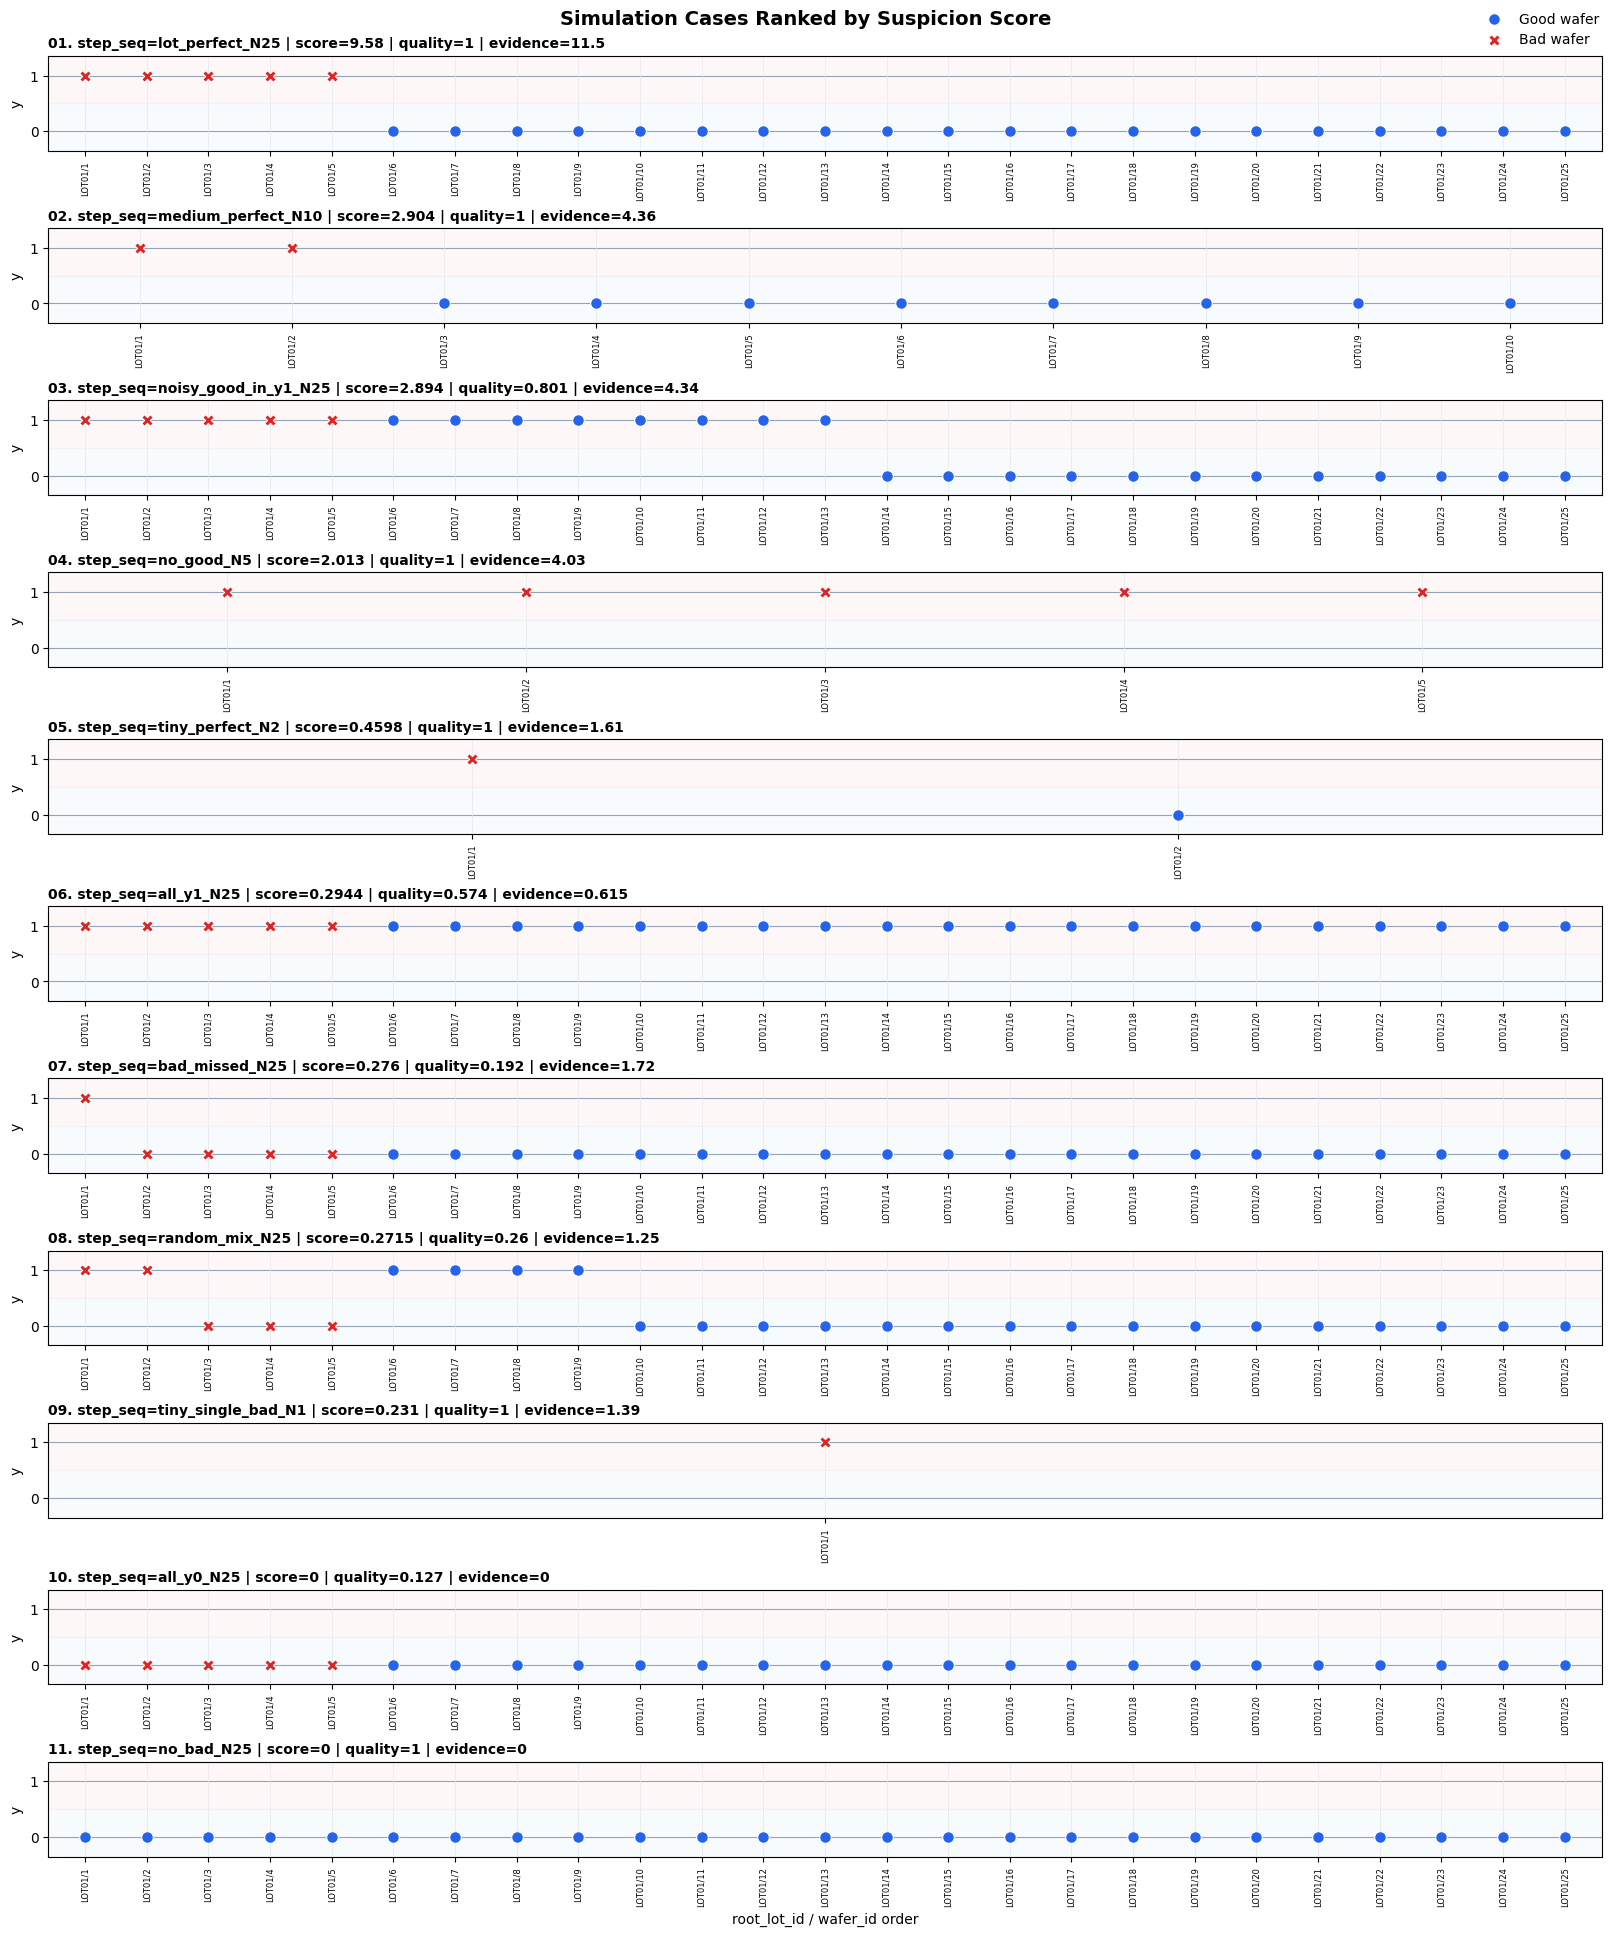

In [4]:
fig = plot_ranked_cases(sim_df, result_df)
plt.show()